<a href="https://colab.research.google.com/github/Jyothik178/Machine-Learning-Skill/blob/main/Week10_2420080039.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                linear = np.dot(xi, self.weights) + self.bias
                y_pred = self.activation(linear)
                update = self.lr * (target - y_pred)

                self.weights += update * xi
                self.bias += update

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.activation(linear)

In [3]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

p = Perceptron()
p.fit(X, y_and)
print("AND:", p.predict(X))

AND: [0 0 0 1]


In [4]:
y_or = np.array([0,1,1,1])

p.fit(X, y_or)
print("OR:", p.predict(X))

OR: [0 1 1 1]


In [5]:

y_xor = np.array([0,1,1,0])

p.fit(X, y_xor)
print("XOR:", p.predict(X))

XOR: [1 1 0 0]


In [6]:

import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self):
        self.W1 = np.random.rand(2, 4)
        self.W2 = np.random.rand(4, 1)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1)
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2)
        self.a2 = sigmoid(self.z2)
        return self.a2

    def train(self, X, y, epochs=10000, lr=0.1):
        for _ in range(epochs):
            output = self.forward(X)

            error = y - output
            d2 = error * sigmoid_deriv(output)

            error_hidden = d2.dot(self.W2.T)
            d1 = error_hidden * sigmoid_deriv(self.a1)

            self.W2 += self.a1.T.dot(d2) * lr
            self.W1 += X.T.dot(d1) * lr


In [7]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

nn = NeuralNetwork()
nn.train(X, y)

print("XOR Output:\n", nn.forward(X))

XOR Output:
 [[0.10355561]
 [0.91693557]
 [0.92469323]
 [0.06279601]]


In [8]:

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

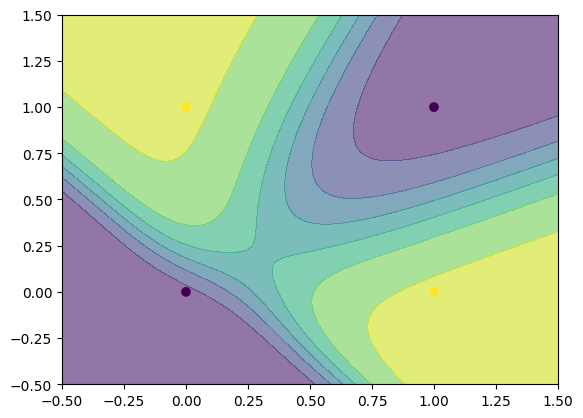

In [9]:
import matplotlib.pyplot as plt

def plot_boundary(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.forward(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.flatten())
    plt.show()

plot_boundary(nn, X, y)

In [10]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

model = Sequential([
    Dense(4, input_dim=2, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X, y, epochs=200, verbose=0)

print("Predictions:", model.predict(X))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predictions: [[0.500887 ]
 [0.5636373]
 [0.500887 ]
 [0.4375963]]


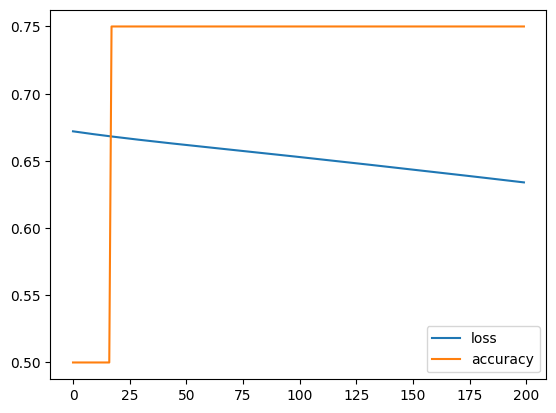

In [11]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.legend()
plt.show()